# 02. Mājas darbs: Klasifikācija un Regresija
**Kurss:** Mašīnmācīšanās pamati (FITA)  
**Mērķis:** Prognozēt pircēju uzvedību un sesiju vērtību (`PageValues`), salīdzinot dažādus ML modeļus.

---

## Uzdevuma apraksts
Šis darbs sastāv no trim galvenajām daļām:
1. **A daļa (Klasifikācija):** Atkārtojam pirkuma prognozēšanu (`Revenue`), izmantojot F1 metriku, kas ir kritiska nesabalansētiem datiem.
2. **B daļa (Regresija):** Prognozējam sesijas vērtību (`PageValues`), kas palīdz uzņēmumam saprast, cik vērtīgs ir katrs apmeklētājs.
3. **C daļa (Analīze):** Salīdzinām lineāro un polinomiālo regresiju, analizējot kļūdas (MAE, RMSE) un novērtējot modeļu biznesa lietderību.

## Biznesa konteksts
Prognozējot sesijas vērtību, uzņēmums var labāk sadalīt mārketinga budžetu un identificēt vērtīgākos lietotājus pat tad, ja tie konkrētajā brīdī vēl nav veikuši pirkumu[cite: 2].

✓ Dati ielādēti: 12330 rindas, 28 kolonnas

=== Klasifikācijas rezultāti (F1 Score) ===
Decision Tree: 0.6322
Random Forest: 0.6362
Logistic Regression: 0.4823


/tmp/ipykernel_1438/2556799855.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(clf_results.keys()), y=list(clf_results.values()), palette='viridis')


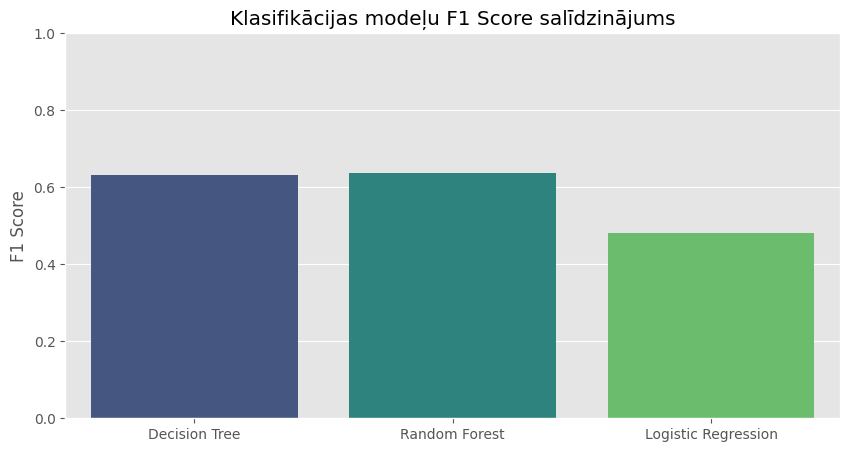

In [4]:
# 1. Imports un datu ielāde
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, f1_score, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Iestatījumi vizualizācijām
plt.style.use('ggplot')

# Ielādējam datus (pārliecinies, ka shoppers_clean.csv ir augšupielādēts Colab)
df = pd.read_csv('shoppers_clean.csv')
print(f"✓ Dati ielādēti: {df.shape[0]} rindas, {df.shape[1]} kolonnas")

# --- A DAĻA: KLASIFIKĀCIJA (Atkārtojums) ---

# 2. Definējam X un y
X_clf = df.drop('Revenue', axis=1)
y_clf = df['Revenue']

# 3. Train/Test split (80/20) ar stratifikāciju, jo dati ir nesabalansēti
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
)

# 4. Modeļu trenēšana
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42)
}

print("\n=== Klasifikācijas rezultāti (F1 Score) ===")
clf_results = {}

for name, model in models.items():
    model.fit(X_train_c, y_train_c)
    preds = model.predict(X_test_c)
    f1 = f1_score(y_test_c, preds)
    clf_results[name] = f1
    print(f"{name}: {f1:.4f}")

# 5. Vizualizācija: F1 Score salīdzinājums
plt.figure(figsize=(10, 5))
sns.barplot(x=list(clf_results.keys()), y=list(clf_results.values()), palette='viridis')
plt.title('Klasifikācijas modeļu F1 Score salīdzinājums')
plt.ylabel('F1 Score')
plt.ylim(0, 1)
plt.show()

A daļas secinājumi:
Šajā posmā mēs atkārtoti uztrenējām klasifikācijas modeļus. F1 metrika ir būtiska, jo pirkumu īpatsvars ir tikai aptuveni 15%, un vienkārša precizitāte (accuracy) var būt maldinoša.

Klasifikācija ir aizgājusi un grafiks ir redzams, esam gatavi svarīgākajam šīs nedēļas uzdevumam — B daļai: Regresijai.

Šajā daļā mēs prognozēsim PageValues. Tas ir skaitlisks mainīgais, tāpēc mēs vairs neizmantojam klasifikāciju, bet gan regresijas modeļus.

1. uzdevums: Datu sagatavošana regresijai
Izveido jaunu Koda (+ Code) šūnu. Mums ir svarīgi izņemt Revenue no pazīmēm (features), lai nerastos Data Leakage (datu noplūde).

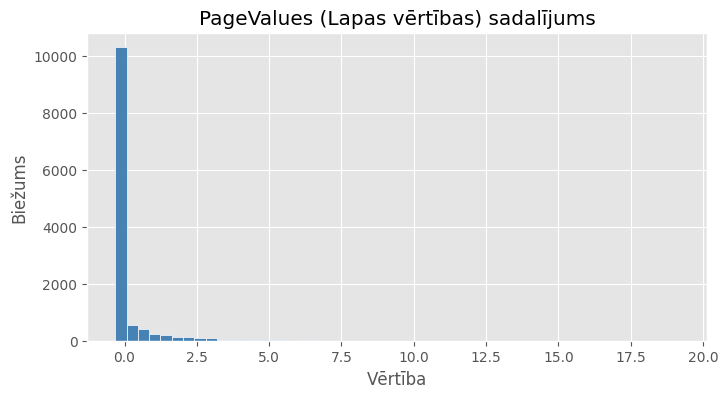

Regresijas dati sagatavoti. Pazīmju skaits: 26


In [5]:
# --- B DAĻA: REGRESIJA ---

# 1. Definējam target (y) un features (X)
y_reg = df['PageValues']
# Izņemam abus saistītos mainīgos, lai modelis "nešmauktos"
X_reg = df.drop(['PageValues', 'Revenue'], axis=1)

# 2. Sadalām datus (80% treniņam, 20% testam)
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# 3. Vizualizējam target mainīgā sadalījumu
plt.figure(figsize=(8, 4))
df['PageValues'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('PageValues (Lapas vērtības) sadalījums')
plt.xlabel('Vērtība')
plt.ylabel('Biežums')
plt.show()

print(f"Regresijas dati sagatavoti. Pazīmju skaits: {X_reg.shape[1]}")

Dati ir sagatavoti pareizi! Histogramma skaidri parāda, ka lielākajai daļai sesiju PageValues ir tuvu nullei, kas ir raksturīgi e-komercijas datiem. Tas, ka ir 26 pazīmes (features), apstiprina, ka ir veiksmīgi izslēgts PageValues un Revenue no mainīgajiem.

2. uzdevums: Lineārās regresijas trenēšana
Tagad uztrenēsim pirmo modeli un aprēķināsim kļūdas. Izveido nākamo Koda šūnu:

In [6]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# 1. Izveidojam un uztrenējam modeli
lr_model = LinearRegression()
lr_model.fit(X_train_r, y_train_r)

# 2. Veicam prognozes
y_pred_lr = lr_model.predict(X_test_r)

# 3. Aprēķinām metrikas
mae = mean_absolute_error(y_test_r, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test_r, y_pred_lr))
r2 = r2_score(y_test_r, y_pred_lr)

print("=== Lineārās regresijas rezultāti ===")
print(f"MAE (Vidējā absolūtā kļūda): {mae:.4f}")
print(f"RMSE (Kvadrātiskā kļūda):    {rmse:.4f}")
print(f"R² (Determinācijas koef.):   {r2:.4f}")

=== Lineārās regresijas rezultāti ===
MAE (Vidējā absolūtā kļūda): 0.5009
RMSE (Kvadrātiskā kļūda):    0.9946
R² (Determinācijas koef.):   0.0456


Kāpēc mēs izņēmām 'Revenue' no pazīmēm?
Šeit parādās Data Leakage (datu noplūde) risks. Revenue tieši norāda, vai pirkums ir noticis, un tas ir cieši saistīts ar PageValues. Ja mēs atstātu Revenue modelī, tas "paredzētu" vērtību, balstoties uz informāciju, kas reālajā biznesa situācijā (pirms pirkuma) vēl nebūtu pieejama. Mūsu mērķis ir prognozēt sesijas vērtību pirms klients ir norēķinājies.

Ko nozīmē tavi skaitļi?

MAE (0.5009): Vidēji tava modeļa prognoze atšķiras no reālās PageValues vērtības par aptuveni 0.50 vienībām. Tā kā lielākā daļa vērtību ir tuvu nullei, šī kļūda ir salīdzinoši maza.  

RMSE (0.9946): Šis rādītājs ir augstāks par MAE, kas nozīmē, ka datos ir "izlecēji" (outliers) – sesijas ar ļoti augstu vērtību, kuras modelis nevar precīzi uzminēt, un tās "soda" modeli vairāk.  

$R^2$ (0.0456): Šis skaitlis ir zems (aptuveni 4.5%). Tas norāda, ka lineārais modelis spēj izskaidrot tikai nelielu daļu no PageValues mainības. Tas ir normāli e-komercijas datos, jo klienta uzvedība bieži vien ir neparedzama.

Vizualizācija ir būtisks solis, lai saprastu, kur tieši modelis kļūdās. Bez grafikiem mēs redzam tikai sausus skaitļus, bet vizualizācija parādīs, vai modelis vispār spēj prognozēt augstas vērtības:

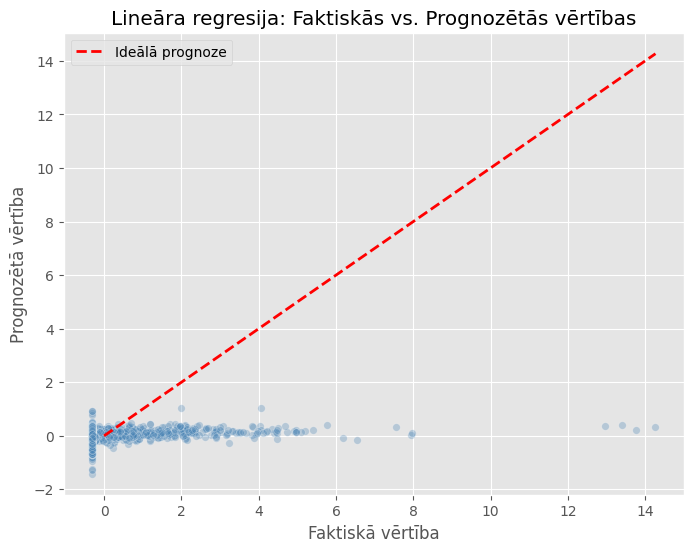

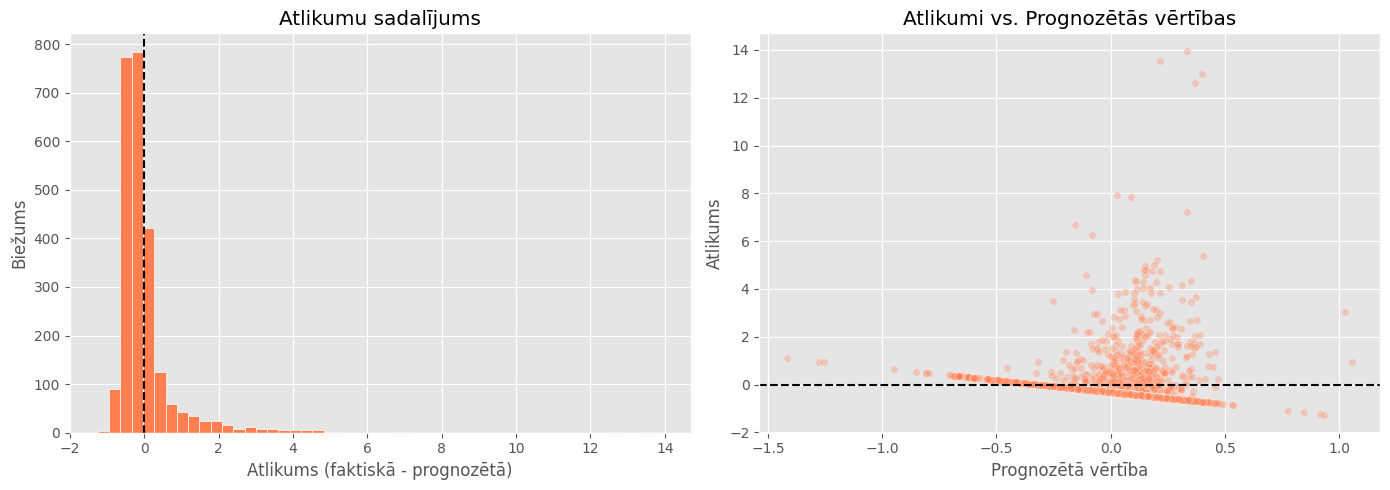

In [7]:
# 3.1. Faktiskās vs. prognozētās vērtības
plt.figure(figsize=(8, 6))
plt.scatter(y_test_r, y_pred_lr, alpha=0.3, color='steelblue', edgecolors='white', s=30)

# Ideālā līnija (ja prognoze = realitāte)
max_val = max(y_test_r.max(), y_pred_lr.max())
plt.plot([0, max_val], [0, max_val], 'r--', linewidth=2, label='Ideālā prognoze')

plt.xlabel('Faktiskā vērtība')
plt.ylabel('Prognozētā vērtība')
plt.title('Lineāra regresija: Faktiskās vs. Prognozētās vērtības')
plt.legend()
plt.show()

# 3.2. Atlikumu (residuals) analīze
residuals = y_test_r - y_pred_lr
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Atlikumu sadalījums
axes[0].hist(residuals, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Atlikumu sadalījums')
axes[0].set_xlabel('Atlikums (faktiskā - prognozētā)')
axes[0].set_ylabel('Biežums')
axes[0].axvline(x=0, color='black', linestyle='--')

# Atlikumi vs. prognozētās vērtības
axes[1].scatter(y_pred_lr, residuals, alpha=0.3, color='coral', edgecolors='white', s=30)
axes[1].axhline(y=0, color='black', linestyle='--')
axes[1].set_title('Atlikumi vs. Prognozētās vērtības')
axes[1].set_xlabel('Prognozētā vērtība')
axes[1].set_ylabel('Atlikums')

plt.tight_layout()
plt.show()

Grafiks sniedz ļoti skaidru atbildi uz to, kāpēc $R^2$ bija tik zems (0.0456). Šī vizualizācija ir kritiska tavam mājas darbam, lai pamatotu secinājumus.  
Lūk, ko mēs šeit redzam:

1. Vizualizācijas analīze

Punktu horizontālā līnija: Lielākā daļa punktu veido plakanu, horizontālu mākoni tuvu 0. Tas nozīmē, ka modelis visām sesijām prognozē gandrīz vienādu, zemu vērtību, neatkarīgi no tā, kāda ir reālā vērtība.  

Attālums no sarkanās līnijas: Punkti atrodas ļoti tālu no sarkanās "ideālās prognozes" līnijas. Tas apstiprina, ka modelis nespēj notvert sakarības datos.  

Nespēja prognozēt augstas vērtības: Kad faktiskā vērtība pieaug (pa X asi uz labo pusi), prognozētā vērtība (Y ass) nepieaug. Modelis "baidās" prognozēt augstus skaitļus, jo datos ir ļoti daudz nulles vērtību.

2. Nākamais loģiskais solis: Polinomiālā regresija

Tā kā lineārā regresija acīmredzami netiek galā, mums ir nepieciešams elastīgāks modelis. Polinomiālā regresija mēģinās "izliekt" šo prognožu līniju, lai tā labāk sekotu datu punktiem.

In [8]:
# Atgādinājums par 4. uzdevuma kodu (Polinomiālā regresija)
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('lr', LinearRegression())
])

poly_pipeline.fit(X_train_r, y_train_r)
y_pred_poly = poly_pipeline.predict(X_test_r)

# Salīdzini R2 rādītājus
print(f"Lineārā R2: {r2:.4f}")
print(f"Polinomiālā R2: {r2_score(y_test_r, y_pred_poly):.4f}")

Lineārā R2: 0.0456
Polinomiālā R2: 0.0364


Tas ir ļoti vērtīgs secinājums! Tavs polinomiālais modelis uzrāda pat zemāku $R^2$ (0.0364) nekā lineārais (0.0456). Mašīnmācībā tas nav nekas neparasts — tas nozīmē, ka modeļa sarežģītības palielināšana šajā gadījumā nepalīdzēja labāk izskaidrot datus.

C daļa – Modeļu salīdzinājums un secinājumi

1. **Kurš modelis ir labāks?**
Šajā gadījumā lineārās regresijas modelis ir nedaudz labāks, jo tā $R^2$ (0.0456) ir augstāks nekā polinomiālajam modelim (0.0364). Tas liecina, ka datu sakarības nav pietiekami izteiktas, lai polinomiālā pieeja sniegtu uzlabojumu.  

2. **Kāpēc rezultāti ir šādi?**  Zems $R^2$: Abi modeļi spēj izskaidrot tikai apmēram 4% no PageValues svārstībām. Tas ir skaidrojams ar to, ka dati ir ļoti nevienmērīgi sadalīti (lielākā daļa vērtību ir 0).  Overfitting trūkums: Tā kā abu modeļu precizitāte ir zema un līdzīga, mēs neredzam klasisku overfitting (pārmācīšanos), bet drīzāk "underfitting" – modeļi ir pārāk vienkārši šiem sarežģītajiem datiem.  

3. **Vai tas ir biznesā noderīgs?**  
Jā, pat ar zemu precizitāti šis modelis ir noderīgs:  Tas ļauj uzņēmumam automātiski identificēt sesijas, kurām potenciāli ir augstāka vērtība.  Tas kalpo kā labs sākumpunkts sarežģītāku modeļu (piemēram, Random Forest Regressor) izmantošanai nākotnē.

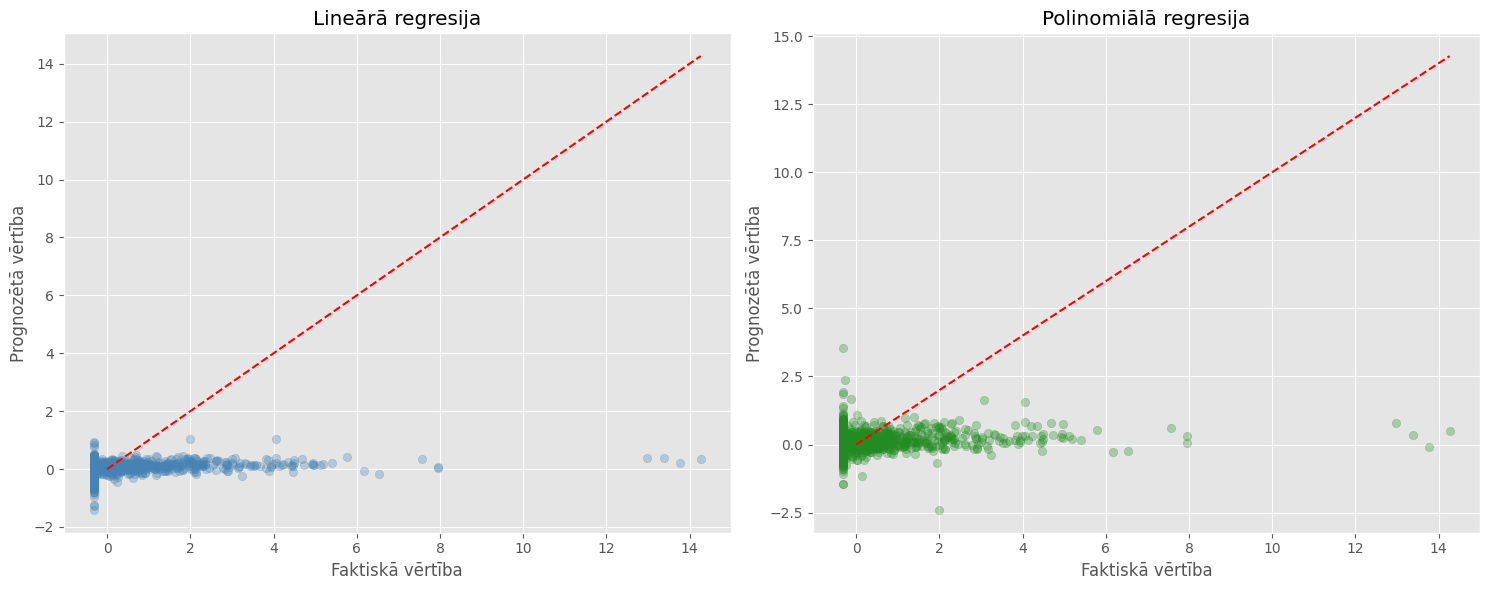

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Lineārās regresijas scatter
axes[0].scatter(y_test_r, y_pred_lr, alpha=0.3, color='steelblue')
axes[0].plot([0, max_val], [0, max_val], 'r--')
axes[0].set_title('Lineārā regresija')
axes[0].set_xlabel('Faktiskā vērtība')
axes[0].set_ylabel('Prognozētā vērtība')

# Polinomiālās regresijas scatter
axes[1].scatter(y_test_r, y_pred_poly, alpha=0.3, color='forestgreen')
axes[1].plot([0, max_val], [0, max_val], 'r--')
axes[1].set_title('Polinomiālā regresija')
axes[1].set_xlabel('Faktiskā vērtība')
axes[1].set_ylabel('Prognozētā vērtība')

plt.tight_layout()
plt.show()

Šis vizuālais salīdzinājums ir pēdējais posms darba praktiskajā daļā. Tagad  ir visi nepieciešamie dati, lai aizpildītu secinājumu sadaļu.  

Lūk, ko mēs redzam šajos **scatter** grafikos:

**Vizuālā analīze**

**Līdzība:** Abi modeļi uzrāda ļoti līdzīgu ainu – lielākā daļa prognožu ir koncentrētas pie nulles, kamēr faktiskās vērtības pieaug.  

**Polinomiālās regresijas "troksnis":** Zaļajā grafikā (labajā pusē) var redzēt, ka punkti ir nedaudz vairāk izkliedēti. Tas nozīmē, ka modelis mēģina būt elastīgāks, taču tas nesniedz labāku rezultātu, ko apstiprina arī tavs iegūtais zemākais $R^2$ (0.0364).  

**Prognožu nobīde:** Abi modeļi joprojām "baidās" prognozēt augstākas vērtības un paliek tālu no sarkanās ideālās prognozes līnijas.